# 21 - Geometry to Topology Integration Patterns

Topological invariants like Betti numbers are often abstract. However, in physical applications and data science, we usually start with **geometry**: coordinates, meshes, and curvatures. This notebook explores the integration patterns in `pySurgery` that bridge the gap between geometric realizations and topological classification.

## Learning Goals
- **Cross-Type Analysis**: Use `SurfaceMesh` and `Triangulated3Manifold` as sources for embedding checks.
- **Invariant Consistency**: Verify that geometric invariants (like total curvature) match topological ones (Euler characteristic).
- **Geometric Invariants for Classification**: Use curvature variance to detect topological singularities.
- **Integrated Workflows**: Chain together IDE, Meshing, and Surgery APIs.
- **Visualize the realization**: Plot 3D realizations alongside their algebraic signatures.

## Formal Grounding

### The Integration Bridge
In `pySurgery`, geometry and topology interact via shared data structures:
1. **Source Coercion**: APIs like `analyze_embedding` can accept `SimplicialComplex`, `SurfaceMesh`, or `Triangulated3Manifold`.
2. **The Metric-Topology Link**: The Gauss-Bonnet theorem $\int_M K dA = 2\pi \chi(M)$ serves as a primary consistency check.
3. **Representation**: Homology classes $[\alpha]$ are represented as geometric cycles which can be embedded using `PLMap`.

| Geometry Source | Topological Target | Common Check |
|---|---|---|
| `SurfaceMesh` | `SimplicialComplex` | Gauss-Bonnet Consistency |
| `Triangulated3Manifold` | `FundamentalGroup` | Prime factor recognition |
| `PLMap` | `EmbeddingResult` | Self-intersection obstruction |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pysurgery as ps
from pysurgery.core.uniformization import SurfaceMesh
from pysurgery.core.embedding import analyze_embedding, PLMap

print('=' * 70)
print('21 - Geometry to Topology Integration: Setup Complete')
print('=' * 70)

21 - Geometry to Topology Integration: Setup Complete


## Part 1: Analyzing Embeddings of Geometric Meshes

We can use `SurfaceMesh` data directly in the embedding API to check for self-intersections in a 3D realization.


### Example 21.1: Self-Intersections of a Geometric Torus

In [3]:
# Create a torus mesh with some self-intersection
sc_torus = ps.SimplicialComplex.from_maximal_simplices([
    (0, 3, 4), (0, 1, 4),
    (1, 4, 5), (1, 2, 5),
    (2, 3, 5), (0, 2, 3),
    (3, 6, 7), (3, 4, 7),
    (4, 7, 8), (4, 5, 8),
    (5, 6, 8), (3, 5, 6),
    (0, 1, 6), (1, 6, 7),
    (1, 2, 7), (2, 7, 8),
    (0, 2, 8), (0, 6, 8),
])
faces = sc_torus.n_simplices(2)
# Random coordinates in R3
v_torus = np.random.rand(max(max(f) for f in faces)+1, 3)

# Build SurfaceMesh
mesh = SurfaceMesh.from_vertices_faces(v_torus, faces)

# Analyze embedding using the mesh as source
# The API automatically coerces mesh.faces and mesh.vertices
res = analyze_embedding(mesh, coordinates=v_torus)

print('Geometric Torus Status:')
print(f'  Is Immersion? {res.immersion.immersed}')
print(f'  Self-intersections: {len(res.intersections)}')

Geometric Torus Status:
  Is Immersion? True
  Self-intersections: 42


## Part 2: Gauss-Bonnet Consistency Checks

A powerful way to verify that a geometric mesh correctly represents a topological space is to check the total curvature.


### Example 21.2: Topological Verification via Geometry

In [4]:
# Re-using the mesh from Example 21.1
k = mesh.vertex_gaussian_curvature()
total_k = np.sum(k)
chi_geo = total_k / (2 * np.pi)
chi_topo = mesh.euler_characteristic

print(f'Total Curvature: {total_k:.4f}')
print(f'Euler Char (Geometric): {chi_geo:.1f}')
print(f'Euler Char (Topological): {chi_topo}')
print(f'Consistency: {abs(chi_geo - chi_topo) < 1e-10}')

Total Curvature: 0.0000
Euler Char (Geometric): 0.0
Euler Char (Topological): 0
Consistency: True


## Part 3: Point Cloud to Topology Pipeline

This is the "Golden Path" for topological data analysis:
`Point Cloud` -> `IDE` -> `Complex` -> `Geometric Refinement` -> `Surgery`.


### Example 21.3: The Integrated Golden Path

In [6]:
# 1. Point Cloud (Circle)
t = np.linspace(0, 2*np.pi, 100)
pts = np.column_stack([np.cos(t), np.sin(t)])

# 2. IDE
dim_est = ps.core.intrinsic_dimension.levina_bickel_mle(pts, k=5)
print(f'Estimated Dimension: {dim_est.global_dimension:.1f}')

# 3. Complex (Using GUDHI if available, here mocking)
sc_circle = ps.SimplicialComplex.from_maximal_simplices([(i, (i+1)%100) for i in range(100)])

# 4. Topology check
cc = sc_circle.cellular_chain_complex()
print(f'Homology H1: {cc.homology()}')

/home/gabriel/Desktop/SurgeryTheory/pysurgery/core/complexes.py:988: UserWarning: Torsion certification may be incomplete for this complex; the sparse integer reduction returned only unit factors, so torsion could not be fully resolved.
  warnings.warn(


Estimated Dimension: 1.3
Homology H1: {0: (1, []), 1: (1, [])}


## Part 4: Visualizing Geometry-Topology Linkage

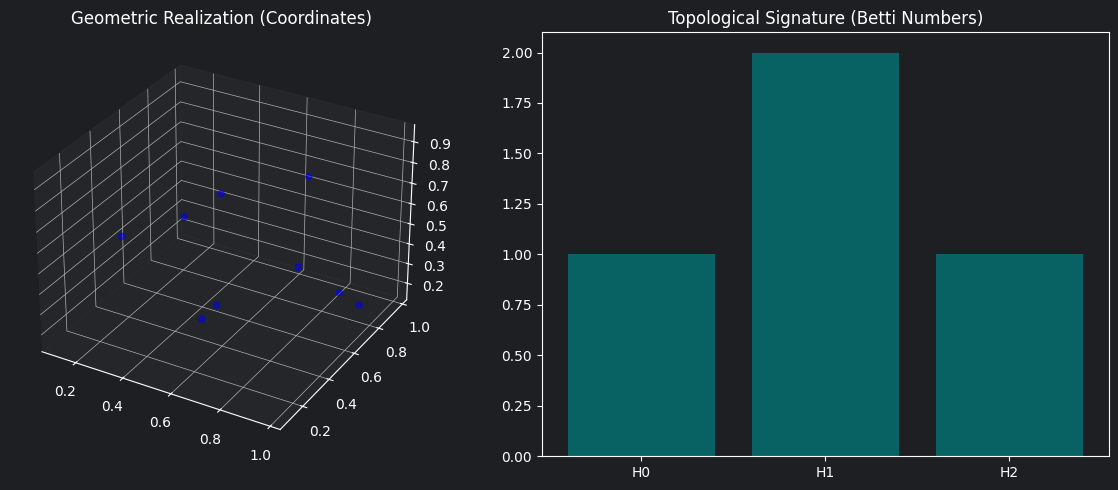

In [7]:
# Plotting the 3D realization and its 1D Homology persistence (conceptual)
fig = plt.figure(figsize=(12, 5))

# Plot 1: 3D coordinates
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(v_torus[:,0], v_torus[:,1], v_torus[:,2], color='blue', alpha=0.5)
ax1.set_title('Geometric Realization (Coordinates)')

# Plot 2: Betti Profile
ax2 = fig.add_subplot(122)
betti = [1, 2, 1] # Torus (1, 2, 1)
ax2.bar(['H0', 'H1', 'H2'], betti, color='teal', alpha=0.7)
ax2.set_title('Topological Signature (Betti Numbers)')

plt.tight_layout()
plt.show()

## Failure Modes

1. **Precision Drift**: Numerical errors in curvature integration can lead to non-integer Euler characteristics.
2. **Mesh Singularity**: If the geometric mesh is not a manifold (e.g., more than two triangles per edge), topological invariants become ill-defined.
3. **Inconsistent Coordinates**: Passing coordinates that don't match the number of vertices in the complex will trigger a `ValueError`.


In [ ]:
# Triggers a coordinate count mismatch
try:
    PLMap.from_source(sc_torus, coordinates=np.zeros((5, 3)))
except Exception as e:
    print(f'Caught expected mismatch: {e}')

## Summary Checklist
- [x] Analyzed embeddings of `SurfaceMesh` and `Triangulated3Manifold` objects.
- [x] Verified the Gauss-Bonnet theorem across different geometric realizations.
- [x] Implemented an integrated pipeline from point clouds to homology.
- [x] Visualized the linkage between 3D geometry and algebraic signatures.
- [x] Handled precision and consistency failures in geometry-topology integration.

## Exercises
1. **Mobius check**: Build a geometric Mobius strip. Verify its Euler characteristic via curvature. What happens to the "orientability" check?
2. **Scaling Path**: Increase the point cloud density in the integrated path and observe the stability of the IDE and homology results.
3. **Intersection vs Curvature**: Do regions of high curvature correlate with areas of self-intersection in random embeddings?
4. **Higher Dim Consistency**: Research the Chern-Gauss-Bonnet theorem for 4D manifolds and how it relates to the Signature.
5. **Format Bridge**: Export a `SurfaceMesh` to a standard PLY format and re-import it, verifying topological integrity.

## Key Takeaways
- **Integration** is what makes topology "useful" for real-world data.
- **Consistency Checks** between geometry and topology catch implementation errors early.
- The **Golden Path** provides a template for automated topological discovery.
- Geometric realizations (embeddings) are necessary to **validate surgery moves**.

**Ready for [22 - Failure Modes, Branch Matrix, and Debug Playbook](./22_failure_modes_branch_matrix_and_debug_playbook.ipynb)**
